In [12]:
## Fountains corner overlaid on Dups MAPQ > 30 ##
import os, subprocess
import pandas as pd
import bioframe
import cooltools
import cooler
import scipy
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
plt.rcParams['font.size']=12

from packaging import version
if version.parse(cooltools.__version__) < version.parse('0.5.2'):
    raise AssertionError("tutorials rely on cooltools version 0.5.2 or higher,"+
                         "please check your cooltools version and update to the latest")

# We can use this function to display a file within the notebook
from IPython.display import Image

In [13]:
import cooltools.lib.plotting
from matplotlib.colors import LogNorm
import bioframe

In [14]:
## Analysis of 2024 MRC5 DpnII data
## Read 2024 RepHiC data


clr_rephic_hu3 = cooler.Cooler('2024-02-and-04-Rep-HiC-HU-MRC5-WT-merged-rerun.merged_sort.MAPQ.30.10k.cool')

clr_rephic_nt3 = cooler.Cooler('2024-02-and-04-Rep-HiC-UT-MRC5-WT-merged-rerun.merged_sort.MAPQ.30.10k.cool')

clr_rephic_hu_g9a3 = cooler.Cooler('2024-02-and-04-Rep-HiC-HU-MRC5-G9ai-merged.merged_sort.MAPQ.30.10k.cool')

clr_rephic_nt_g9a3 = cooler.Cooler('2024-02-and-04-Rep-HiC-UT-MRC5-G9ai-merged.merged_sort.MAPQ.30.10k.cool')

clr_hic_hu3 = cooler.Cooler('2024-02-16-HiC-HU-MRC5-WT.merged_sort.MAPQ.30.10k.cool')

clr_hic_nt3 = cooler.Cooler('2024-02-16-HiC-NT-MRC5-WT.merged_sort.MAPQ.30.10k.cool')

clr_hic_hu_g9a3 = cooler.Cooler('2025-11-12-HiC-HU-MRC5-G9ai.merged_sort.MAPQ.30.10k.cool')

clr_hic_nt_g9a3 = cooler.Cooler('2025-11-12-HiC-UT-MRC5-G9ai.merged_sort.MAPQ.30.10k.cool')

In [15]:
## 10kb and 25kb resolution combined fountain files

## Resolution and flank parameters
flank = 250_000
resolution = 10000

################Cooler file for calculating EXPECTED###############

## Read 2024 Fountain (HU+UT) combined bed file ##

fountain_anchors = bioframe.read_table('2024-02-and-04-Rep-HiC-HU-and-UT.10k-and-25k.combined.Full.Fountains.bedpe', schema='bedpe')

# fountain_bed.columns = ['chrom', 'start', 'end']

# rephic_ut_2 = clr_rephic_nt3
# rephic_hu_2 = clr_rephic_hu3

# hic_ut_2 = clr_hic_nt3
# hic_hu_2 = clr_hic_hu3

# rephic_ut_2 = clr_rephic_nt3
# hic_ut_2 = clr_hic_nt3

# rephic_hu_2 = clr_rephic_hu3
# hic_hu_2 = clr_hic_hu3

# rephic_ut_g9a_2 = clr_rephic_nt_g9a3
# hic_ut_g9a_2 = clr_hic_nt_g9a3

# rephic_hu_g9a_2 = clr_rephic_hu_g9a3
# hic_hu_g9a_2 = clr_hic_hu_g9a3

rephic_ut_2 = clr_rephic_nt3
hic_ut_2 = clr_hic_nt3

rephic_hu_2 = clr_rephic_hu3
hic_hu_2 = clr_hic_hu3

rephic_hu_g9a_2 = clr_rephic_hu_g9a3
hic_hu_g9a_2 = clr_hic_hu_g9a3 

rephic_ut_g9a_2 = clr_rephic_nt_g9a3
hic_ut_g9a_2 = clr_hic_nt_g9a3 

expected1 = cooltools.expected_cis(hic_hu_2, nproc=16, chunksize=100_000)
stack1 = cooltools.pileup(rephic_hu_2, fountain_anchors, expected_df=expected1, nproc=16, flank=flank)
mtx1 = np.nanmean(stack1, axis=0)

expected2 = cooltools.expected_cis(hic_ut_2, nproc=16, chunksize=100_000)
stack2 = cooltools.pileup(rephic_ut_2, fountain_anchors, expected_df=expected2, nproc=16, flank=flank)
mtx2 = np.nanmean(stack2, axis=0)

expected3 = cooltools.expected_cis(hic_hu_g9a_2, nproc=16, chunksize=100_000)
stack3 = cooltools.pileup(rephic_hu_g9a_2, fountain_anchors, expected_df=expected3, nproc=16, flank=flank)
mtx3 = np.nanmean(stack3, axis=0)

expected4 = cooltools.expected_cis(hic_ut_g9a_2, nproc=16, chunksize=100_000)
stack4 = cooltools.pileup(rephic_ut_g9a_2, fountain_anchors, expected_df=expected4, nproc=16, flank=flank)
mtx4 = np.nanmean(stack4, axis=0)


# stack1 = cooltools.pileup(rephic_hu_2, fountain_anchors, nproc=16, flank=flank)
# mtx1 = np.nanmean(stack1, axis=0)


# stack2 = cooltools.pileup(rephic_ut_2, fountain_anchors, nproc=16, flank=flank)
# mtx2 = np.nanmean(stack2, axis=0)


# stack3 = cooltools.pileup(rephic_hu_g9a_2, fountain_anchors, nproc=16, flank=flank)
# mtx3 = np.nanmean(stack3, axis=0)


# stack4 = cooltools.pileup(rephic_hu_2, fountain_anchors, nproc=16, flank=flank)
# mtx4 = np.nanmean(stack4, axis=0)

INFO:root:creating a Pool of 16 workers
INFO:root:creating a Pool of 16 workers
INFO:root:creating a Pool of 16 workers
INFO:root:creating a Pool of 16 workers
INFO:root:creating a Pool of 16 workers
INFO:root:creating a Pool of 16 workers
INFO:root:creating a Pool of 16 workers
INFO:root:creating a Pool of 16 workers


/var/folders/c0/r1z251qj2mvczjs_mvjhpzqr0000gn/T/ipykernel_3820/250763200.py:112: RuntimeWarning: invalid value encountered in log2
  np.log2(mtx1-mtx2),
/var/folders/c0/r1z251qj2mvczjs_mvjhpzqr0000gn/T/ipykernel_3820/250763200.py:135: RuntimeWarning: invalid value encountered in log2
  np.log2(mtx1-mtx3),
/var/folders/c0/r1z251qj2mvczjs_mvjhpzqr0000gn/T/ipykernel_3820/250763200.py:158: RuntimeWarning: invalid value encountered in log2
  np.log2(mtx2-mtx3),
/var/folders/c0/r1z251qj2mvczjs_mvjhpzqr0000gn/T/ipykernel_3820/250763200.py:181: RuntimeWarning: invalid value encountered in log2
  np.log2(mtx4-mtx3),


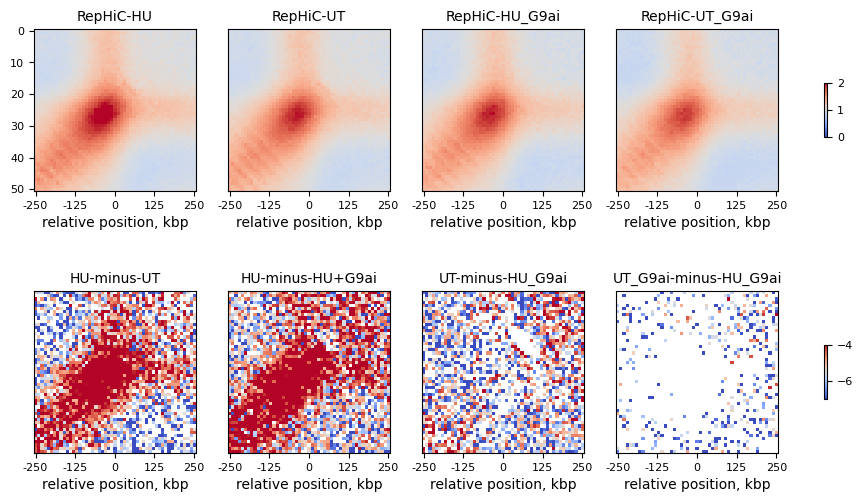

In [5]:
## APA on Rep-HiC dups data

fig, axs = plt.subplots(nrows=2, ncols=4,
    figsize=(12, 12))

plt.subplots_adjust(bottom=0.3, top=0.7, hspace=0.2, wspace=0.2)

ticks_pixels = np.linspace(0, flank*2//resolution,5)
ticks_kbp = ((ticks_pixels-ticks_pixels[-1]/2)*resolution//1000).astype(int)

ax = axs[0,0]
im1 = ax.imshow(
    (mtx1),
    vmax = 2,
    vmin = 0,
    cmap='coolwarm')

# Add colorbar and set tick font size
# cbar = fig.colorbar(im1, ax=axs[0], shrink = 0.25)
# cbar.ax.tick_params(labelsize=8)  # Adjust font size of colorbar ticks

ax.set(title='RepHiC-HU',
           xticks=ticks_pixels,
           xticklabels=ticks_kbp,
           xlabel='relative position, kbp')

# Adjust font size for title, labels, and tick labels
ax.title.set_fontsize(10)           # Font size for the title
ax.xaxis.label.set_fontsize(10)     # Font size for the x-axis label
ax.yaxis.label.set_fontsize(10)     # Font size for the y-axis label (if you set one)
ax.tick_params(axis='x', labelsize=8)  # Font size for x-axis tick labels
ax.tick_params(axis='y', labelsize=8)  # Font size for y-axis tick labels (if needed)
# # Remove the y-axis label and tick marks
# ax.set_ylabel('')  # Removes the y-axis label
# ax.tick_params(axis='y', which='both', left=False, labelleft=False)  # Removes y-axis ticks and tick labels

ax = axs[0,1]
im2 = ax.imshow(
    (mtx2),
    vmax = 2,
    vmin = 0,
    cmap='coolwarm')


# Add colorbar and set tick font size
# cbar = fig.colorbar(im2, ax=axs[0], shrink = 0.25)
# cbar.ax.tick_params(labelsize=8)  # Adjust font size of colorbar ticks

ax.set(title='RepHiC-UT',
           xticks=ticks_pixels,
           xticklabels=ticks_kbp,
           xlabel='relative position, kbp')

# Adjust font size for title, labels, and tick labels
ax.title.set_fontsize(10)           # Font size for the title
ax.xaxis.label.set_fontsize(10)     # Font size for the x-axis label
ax.yaxis.label.set_fontsize(10)     # Font size for the y-axis label (if you set one)
ax.tick_params(axis='x', labelsize=8)  # Font size for x-axis tick labels
ax.tick_params(axis='y', labelsize=8)  # Font size for y-axis tick labels (if needed)
# Remove the y-axis label and tick marks
ax.set_ylabel('')  # Removes the y-axis label
ax.tick_params(axis='y', which='both', left=False, labelleft=False)  # Removes y-axis ticks and tick labels

ax = axs[0,2]
im2 = ax.imshow(
    (mtx3),
    vmax = 2,
    vmin = 0,
    cmap='coolwarm')
# Add colorbar and set tick font size
# cbar = fig.colorbar(im2, ax=axs[0], shrink = 0.25)
# cbar.ax.tick_params(labelsize=8)  # Adjust font size of colorbar ticks
ax.set(title='RepHiC-HU_G9ai',
           xticks=ticks_pixels,
           xticklabels=ticks_kbp,
           xlabel='relative position, kbp')
# Adjust font size for title, labels, and tick labels
ax.title.set_fontsize(10)           # Font size for the title
ax.xaxis.label.set_fontsize(10)     # Font size for the x-axis label
ax.yaxis.label.set_fontsize(10)     # Font size for the y-axis label (if you set one)
ax.tick_params(axis='x', labelsize=8)  # Font size for x-axis tick labels
ax.tick_params(axis='y', labelsize=8)  # Font size for y-axis tick labels (if needed)
# Remove the y-axis label and tick marks
ax.set_ylabel('')  # Removes the y-axis label
ax.tick_params(axis='y', which='both', left=False, labelleft=False)  # Removes y-axis ticks and tick labels

ax = axs[0,3]
im2 = ax.imshow(
    (mtx4),
    vmax = 2,
    vmin = 0,
    cmap='coolwarm')
# Add colorbar and set tick font size
cbar = fig.colorbar(im2, ax=axs[0], shrink = 0.25)
cbar.ax.tick_params(labelsize=8)  # Adjust font size of colorbar ticks
ax.set(title='RepHiC-UT_G9ai',
           xticks=ticks_pixels,
           xticklabels=ticks_kbp,
           xlabel='relative position, kbp')
# Adjust font size for title, labels, and tick labels
ax.title.set_fontsize(10)           # Font size for the title
ax.xaxis.label.set_fontsize(10)     # Font size for the x-axis label
ax.yaxis.label.set_fontsize(10)     # Font size for the y-axis label (if you set one)
ax.tick_params(axis='x', labelsize=8)  # Font size for x-axis tick labels
ax.tick_params(axis='y', labelsize=8)  # Font size for y-axis tick labels (if needed)
# Remove the y-axis label and tick marks
ax.set_ylabel('')  # Removes the y-axis label
ax.tick_params(axis='y', which='both', left=False, labelleft=False)  # Removes y-axis ticks and tick labels

ax = axs[1,0]
im3 = ax.imshow(
    np.log2(mtx1-mtx2),
    vmax =-4,
    vmin = -7,
    cmap='coolwarm')
# Add colorbar and set tick font size
# cbar = fig.colorbar(im3, ax=axs[1], shrink = 0.25)
# cbar.ax.tick_params(labelsize=8)  # Adjust font size of colorbar ticks
ax.set(title='HU-minus-UT',
           xticks=ticks_pixels,
           xticklabels=ticks_kbp,
           xlabel='relative position, kbp')
# Adjust font size for title, labels, and tick labels
ax.title.set_fontsize(10)           # Font size for the title
ax.xaxis.label.set_fontsize(10)     # Font size for the x-axis label
ax.yaxis.label.set_fontsize(10)     # Font size for the y-axis label (if you set one)
ax.tick_params(axis='x', labelsize=8)  # Font size for x-axis tick labels
ax.tick_params(axis='y', labelsize=8)  # Font size for y-axis tick labels (if needed)
# Remove the y-axis label and tick marks
ax.set_ylabel('')  # Removes the y-axis label
ax.tick_params(axis='y', which='both', left=False, labelleft=False)  # Removes y-axis ticks and tick labels

ax = axs[1,1]
im3 = ax.imshow(
    np.log2(mtx1-mtx3),
    vmax =-4,
    vmin = -7,
    cmap='coolwarm')
# Add colorbar and set tick font size
# cbar = fig.colorbar(im3, ax=axs[1], shrink = 0.25)
# cbar.ax.tick_params(labelsize=8)  # Adjust font size of colorbar ticks
ax.set(title='HU-minus-HU+G9ai',
           xticks=ticks_pixels,
           xticklabels=ticks_kbp,
           xlabel='relative position, kbp')
# Adjust font size for title, labels, and tick labels
ax.title.set_fontsize(10)           # Font size for the title
ax.xaxis.label.set_fontsize(10)     # Font size for the x-axis label
ax.yaxis.label.set_fontsize(10)     # Font size for the y-axis label (if you set one)
ax.tick_params(axis='x', labelsize=8)  # Font size for x-axis tick labels
ax.tick_params(axis='y', labelsize=8)  # Font size for y-axis tick labels (if needed)
# Remove the y-axis label and tick marks
ax.set_ylabel('')  # Removes the y-axis label
ax.tick_params(axis='y', which='both', left=False, labelleft=False)  # Removes y-axis ticks and tick labels

ax = axs[1,2]
im3 = ax.imshow(
    np.log2(mtx2-mtx3),
    vmax =-4,
    vmin = -7,
    cmap='coolwarm')
# Add colorbar and set tick font size
# cbar = fig.colorbar(im3, ax=axs[1], shrink = 0.25)
# cbar.ax.tick_params(labelsize=8)  # Adjust font size of colorbar ticks
ax.set(title='UT-minus-HU_G9ai',
           xticks=ticks_pixels,
           xticklabels=ticks_kbp,
           xlabel='relative position, kbp')
# Adjust font size for title, labels, and tick labels
ax.title.set_fontsize(10)           # Font size for the title
ax.xaxis.label.set_fontsize(10)     # Font size for the x-axis label
ax.yaxis.label.set_fontsize(10)     # Font size for the y-axis label (if you set one)
ax.tick_params(axis='x', labelsize=8)  # Font size for x-axis tick labels
ax.tick_params(axis='y', labelsize=8)  # Font size for y-axis tick labels (if needed)
# Remove the y-axis label and tick marks
ax.set_ylabel('')  # Removes the y-axis label
ax.tick_params(axis='y', which='both', left=False, labelleft=False)  # Removes y-axis ticks and tick labels

ax = axs[1,3]
im3 = ax.imshow(
    np.log2(mtx4-mtx3),
    vmax =-4,
    vmin = -7,
    cmap='coolwarm')
# Add colorbar and set tick font size
cbar = fig.colorbar(im3, ax=axs[1], shrink = 0.25)
cbar.ax.tick_params(labelsize=8)  # Adjust font size of colorbar ticks
ax.set(title='UT_G9ai-minus-HU_G9ai',
           xticks=ticks_pixels,
           xticklabels=ticks_kbp,
           xlabel='relative position, kbp')
# Adjust font size for title, labels, and tick labels
ax.title.set_fontsize(10)           # Font size for the title
ax.xaxis.label.set_fontsize(10)     # Font size for the x-axis label
ax.yaxis.label.set_fontsize(10)     # Font size for the y-axis label (if you set one)
ax.tick_params(axis='x', labelsize=8)  # Font size for x-axis tick labels
ax.tick_params(axis='y', labelsize=8)  # Font size for y-axis tick labels (if needed)
# Remove the y-axis label and tick marks
ax.set_ylabel('')  # Removes the y-axis label
ax.tick_params(axis='y', which='both', left=False, labelleft=False)  # Removes y-axis ticks and tick labels

plt.savefig("../fig_1/2024-02-and-04-Rep-HiC-HU-and-UT.10k-and-25k.combined.aggregate.Fountains.anchor.interaction.v2.pdf",\
            bbox_inches='tight', dpi=1200, format = 'pdf')

plt.show()

# axs[0,0].set(yticks=ticks_pixels,
#        yticklabels=ticks_kbp,
#        ylabel='relative position, kbp')
#plt.show()

In [16]:
np.savetxt("../fig_1/UT_corner_dot.csv", mtx2, delimiter=",")
np.savetxt("../fig_1/HU_corner_dot.csv", mtx1, delimiter=",")
np.savetxt("../fig_1/HU+G9ai_conner_dot.csv", mtx3, delimiter=",")
np.savetxt("../fig_1/UT+G9ai_corner_dots.csv", mtx4, delimiter=",")

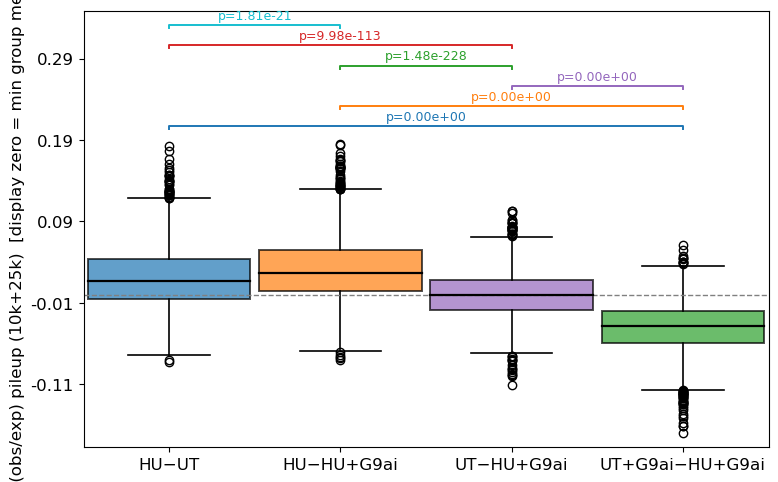

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy.stats import ttest_ind

def flat_valid(m):
    a = np.asarray(m, float).ravel()
    return a[np.isfinite(a)]

# ------ contrasts (unchanged) ------
v1 = flat_valid(mtx1  - mtx2)    # HU − UT
v2 = flat_valid(mtx1  - mtx3)    # HU − HU+G9ai
v3 = flat_valid(mtx2  - mtx3)    # UT − HU+G9ai
v4 = flat_valid(mtx4  - mtx3)   # HU+G9ai − UT+G9ai

data   = [v1, v2, v3, v4]
labels = ["HU−UT", "HU−HU+G9ai", "UT−HU+G9ai", "UT+G9ai−HU+G9ai"]

df = pd.DataFrame({
    "HU_minus_UT"        : v1,  # mtx7 - mtx5
    "HU_minus_HU_G9ai"   : v2,  # mtx7 - mtx9
    "UT_minus_HU_G9ai"   : v3,  # mtx5 - mtx9
    "HU_G9ai_minus_UT_G9ai": v4 # mtx9 - mtx11
})

# saves all four columns in the same Excel file / same sheet
df.to_excel("../fig_1/matrix_corner_dot_aggr.xlsx", index=False)


# ------ find offset but DON'T modify data ------
means  = [np.mean(v) for v in data]
offset = means[2]  # this mean should appear as 0 on the axis

# ------ colors ------
colors = ["#1f77b4", "#ff7f0e", "#9467bd", "#2ca02c"]

# ------ p-values on RAW data (no shifting) ------
pairs = []
for i in range(4):
    for j in range(i+1, 4):
        _, p = ttest_ind(data[i], data[j], equal_var=False)
        pairs.append(((i+1, j+1), p))  # 1-based positions

# ------ limits & bracket start from GLOBAL max of RAW data ------
all_vals = np.concatenate(data)
gmin = float(np.nanmin(all_vals))
gmax = float(np.nanmax(all_vals))
span = max(gmax - gmin, 1e-9)

ymin = gmin - 0.05*span
ymax = gmax + 0.15*span

br_start = gmax + 0.05*span
br_step  = 0.07*span
top_needed = br_start + (len(pairs)-1)*br_step + 0.06*span
ymax = max(ymax, top_needed)

# ------ plot ------
fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(data, labels=labels, widths=0.95, patch_artist=True, showfliers=True)

# color boxes
for box, c in zip(bp["boxes"], colors):
    box.set_facecolor(c); box.set_alpha(0.7)
    box.set_edgecolor("black"); box.set_linewidth(1.4)
for med in bp["medians"]:
    med.set_color("black"); med.set_linewidth(1.6)
for w in bp["whiskers"]:
    w.set_color("black"); w.set_linewidth(1.2)
for cap in bp["caps"]:
    cap.set_color("black"); cap.set_linewidth(1.2)

# axis limits
ax.set_ylim(ymin, ymax)

# dotted baseline at the OFFSET (will be labeled as 0)
ax.axhline(offset, ls="--", lw=1, color="gray")

# y-tick formatter to DISPLAY values relative to offset (no data change)
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{(y - offset):.2g}"))
ax.set_ylabel("Δ(obs/exp) pileup (10k+25k)  [display zero = min group mean]")

# colored brackets & labels
bracket_colors = ["#1f77b4", "#ff7f0e", "#9467bd", "#2ca02c", "#d62728", "#17becf"]
for k, ((x1, x2), p) in enumerate(sorted(pairs, key=lambda x: x[1])):  # smallest p on top
    c = bracket_colors[k % len(bracket_colors)]
    y = br_start + k*br_step
    ax.plot([x1, x1, x2, x2], [y, y+0.01*span, y+0.01*span, y], color=c, lw=1.4)
    ax.text((x1+x2)/2, y+0.02*span, f"p={p:.2e}", ha="center", va="bottom", fontsize=9, color=c)

plt.tight_layout()
plt.savefig("../fig_1/corner_dot_boxplot_all_pairs.svg", dpi=1200)
plt.show()


/var/folders/c0/r1z251qj2mvczjs_mvjhpzqr0000gn/T/ipykernel_3820/1455578701.py:102: RuntimeWarning: invalid value encountered in log2
  np.log2(scipy.ndimage.gaussian_filter(mtx1-mtx2, sigma=3)),


[[<matplotlib.axis.YTick at 0x7f7a5ac05430>,
 [Text(0, 0.0, '-250'),
  Text(0, 12.5, '-125'),
  Text(0, 25.0, '0'),
  Text(0, 37.5, '125'),
  Text(0, 50.0, '250')],
 Text(0, 0.5, 'relative position, kbp')]

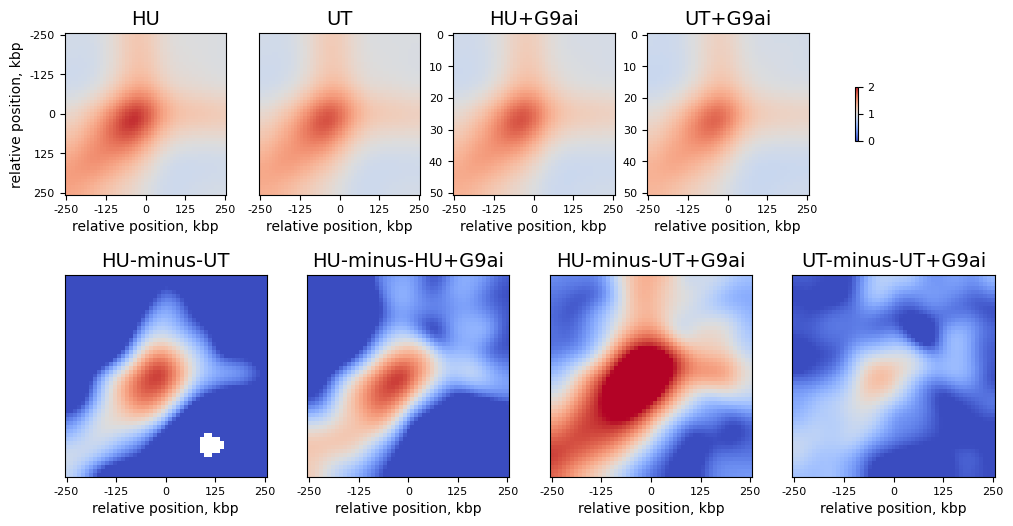

In [7]:
## APA on Rep-HiC dups data

fig, axs = plt.subplots(nrows=2, ncols=4,
    figsize=(12, 12))

plt.subplots_adjust(bottom=0.3, top=0.7, hspace=0.2, wspace=0.2)

ticks_pixels = np.linspace(0, flank*2//resolution,5)
ticks_kbp = ((ticks_pixels-ticks_pixels[-1]/2)*resolution//1000).astype(int)

ax = axs[0,0]
im1 = ax.imshow(
    scipy.ndimage.gaussian_filter(mtx1, sigma=3),
    vmax = 2,
    vmin = 0,
    cmap='coolwarm')
# Add colorbar and set tick font size
# cbar = fig.colorbar(im1, ax=axs[0], shrink = 0.25)
# cbar.ax.tick_params(labelsize=8)  # Adjust font size of colorbar ticks
ax.set(title='HU',
           xticks=ticks_pixels,
           xticklabels=ticks_kbp,
           xlabel='relative position, kbp')

# Adjust font size for title, labels, and tick labels
ax.title.set_fontsize(14)           # Font size for the title
ax.xaxis.label.set_fontsize(10)     # Font size for the x-axis label
ax.yaxis.label.set_fontsize(10)     # Font size for the y-axis label (if you set one)
ax.tick_params(axis='x', labelsize=8)  # Font size for x-axis tick labels
ax.tick_params(axis='y', labelsize=8)  # Font size for y-axis tick labels (if needed)
# # Remove the y-axis label and tick marks
# ax.set_ylabel('')  # Removes the y-axis label
# ax.tick_params(axis='y', which='both', left=False, labelleft=False)  # Removes y-axis ticks and tick labels

ax = axs[0,1]
im2 = ax.imshow(
    scipy.ndimage.gaussian_filter(mtx2, sigma=3),
    vmax = 2,
    vmin = 0,
    cmap='coolwarm')
# Add colorbar and set tick font size
# cbar = fig.colorbar(im2, ax=axs[1], shrink = 0.25)
# cbar.ax.tick_params(labelsize=8)  # Adjust font size of colorbar ticks
ax.set(title='UT',
           xticks=ticks_pixels,
           xticklabels=ticks_kbp,
           xlabel='relative position, kbp')
# Adjust font size for title, labels, and tick labels
ax.title.set_fontsize(14)           # Font size for the title
ax.xaxis.label.set_fontsize(10)     # Font size for the x-axis label
ax.yaxis.label.set_fontsize(10)     # Font size for the y-axis label (if you set one)
ax.tick_params(axis='x', labelsize=8)  # Font size for x-axis tick labels
ax.tick_params(axis='y', labelsize=8)  # Font size for y-axis tick labels (if needed)
# Remove the y-axis label and tick marks
ax.set_ylabel('')  # Removes the y-axis label
ax.tick_params(axis='y', which='both', left=False, labelleft=False)  # Removes y-axis ticks and tick labels

ax = axs[0,2]
im1 = ax.imshow(
    scipy.ndimage.gaussian_filter(mtx3, sigma=3),
    vmax = 2,
    vmin = 0,
    cmap='coolwarm')
# Add colorbar and set tick font size
# cbar = fig.colorbar(im1, ax=axs[0], shrink = 0.25)
# cbar.ax.tick_params(labelsize=8)  # Adjust font size of colorbar ticks
ax.set(title='HU+G9ai',
           xticks=ticks_pixels,
           xticklabels=ticks_kbp,
           xlabel='relative position, kbp')
# Adjust font size for title, labels, and tick labels
ax.title.set_fontsize(14)           # Font size for the title
ax.xaxis.label.set_fontsize(10)     # Font size for the x-axis label
ax.yaxis.label.set_fontsize(10)     # Font size for the y-axis label (if you set one)
ax.tick_params(axis='x', labelsize=8)  # Font size for x-axis tick labels
ax.tick_params(axis='y', labelsize=8)  # Font size for y-axis tick labels (if needed)

ax = axs[0,3]
im1 = ax.imshow(
    scipy.ndimage.gaussian_filter(mtx4, sigma=3),
    vmax = 2,
    vmin = 0,
    cmap='coolwarm')
# Add colorbar and set tick font size
cbar = fig.colorbar(im1, ax=axs[0], shrink = 0.25)
cbar.ax.tick_params(labelsize=8)  # Adjust font size of colorbar ticks
ax.set(title='UT+G9ai',
           xticks=ticks_pixels,
           xticklabels=ticks_kbp,
           xlabel='relative position, kbp')

# Adjust font size for title, labels, and tick labels
ax.title.set_fontsize(14)           # Font size for the title
ax.xaxis.label.set_fontsize(10)     # Font size for the x-axis label
ax.yaxis.label.set_fontsize(10)     # Font size for the y-axis label (if you set one)
ax.tick_params(axis='x', labelsize=8)  # Font size for x-axis tick labels
ax.tick_params(axis='y', labelsize=8)  # Font size for y-axis tick labels (if needed)
#################################################
#################################################
ax = axs[1,0]
im3 = ax.imshow(
    np.log2(scipy.ndimage.gaussian_filter(mtx1-mtx2, sigma=3)),
    vmax =-3,
    vmin = -5,
    cmap='coolwarm')
# Add colorbar and set tick font size
# cbar = fig.colorbar(im3, ax=axs[2], shrink = 0.25)
# cbar.ax.tick_params(labelsize=8)  # Adjust font size of colorbar ticks
ax.set(title='HU-minus-UT',
           xticks=ticks_pixels,
           xticklabels=ticks_kbp,
           xlabel='relative position, kbp')
# Adjust font size for title, labels, and tick labels
ax.title.set_fontsize(14)           # Font size for the title
ax.xaxis.label.set_fontsize(10)     # Font size for the x-axis label
ax.yaxis.label.set_fontsize(10)     # Font size for the y-axis label (if you set one)
ax.tick_params(axis='x', labelsize=8)  # Font size for x-axis tick labels
ax.tick_params(axis='y', labelsize=8)  # Font size for y-axis tick labels (if needed)
# Remove the y-axis label and tick marks
ax.set_ylabel('')  # Removes the y-axis label
ax.tick_params(axis='y', which='both', left=False, labelleft=False)  # Removes y-axis ticks and tick labels

ax = axs[1,1]
im3 = ax.imshow(
    np.log2(scipy.ndimage.gaussian_filter(mtx1-mtx3, sigma=3)),
    vmax =-3,
    vmin = -5,
    cmap='coolwarm')
# Add colorbar and set tick font size
# cbar = fig.colorbar(im3, ax=axs[1], shrink = 0.25)
# cbar.ax.tick_params(labelsize=8)  # Adjust font size of colorbar ticks
ax.set(title='HU-minus-HU+G9ai',
           xticks=ticks_pixels,
           xticklabels=ticks_kbp,
           xlabel='relative position, kbp')
# Adjust font size for title, labels, and tick labels
ax.title.set_fontsize(14)           # Font size for the title
ax.xaxis.label.set_fontsize(10)     # Font size for the x-axis label
ax.yaxis.label.set_fontsize(10)     # Font size for the y-axis label (if you set one)
ax.tick_params(axis='x', labelsize=8)  # Font size for x-axis tick labels
ax.tick_params(axis='y', labelsize=8)  # Font size for y-axis tick labels (if needed)
# Remove the y-axis label and tick marks
ax.set_ylabel('')  # Removes the y-axis label
ax.tick_params(axis='y', which='both', left=False, labelleft=False)  # Removes y-axis ticks and tick labels

ax = axs[1,2]
im3 = ax.imshow(
    np.log2(scipy.ndimage.gaussian_filter(mtx1-mtx4, sigma=3)),
    vmax =-3,
    vmin = -5,
    cmap='coolwarm')
# Add colorbar and set tick font size
# cbar = fig.colorbar(im3, ax=axs[1], shrink = 0.25)
# cbar.ax.tick_params(labelsize=8)  # Adjust font size of colorbar ticks
ax.set(title='HU-minus-UT+G9ai',
           xticks=ticks_pixels,
           xticklabels=ticks_kbp,
           xlabel='relative position, kbp')
# Adjust font size for title, labels, and tick labels
ax.title.set_fontsize(14)           # Font size for the title
ax.xaxis.label.set_fontsize(10)     # Font size for the x-axis label
ax.yaxis.label.set_fontsize(10)     # Font size for the y-axis label (if you set one)
ax.tick_params(axis='x', labelsize=8)  # Font size for x-axis tick labels
ax.tick_params(axis='y', labelsize=8)  # Font size for y-axis tick labels (if needed)
# Remove the y-axis label and tick marks
ax.set_ylabel('')  # Removes the y-axis label
ax.tick_params(axis='y', which='both', left=False, labelleft=False)  # Removes y-axis ticks and tick labels

ax = axs[1,3]
im3 = ax.imshow(
    np.log2(scipy.ndimage.gaussian_filter(mtx2-mtx4, sigma=3)),
    vmax =-3,
    vmin = -5,
    cmap='coolwarm')
# Add colorbar and set tick font size
# cbar = fig.colorbar(im3, ax=axs[1], shrink = 0.25)
# cbar.ax.tick_params(labelsize=8)  # Adjust font size of colorbar ticks
ax.set(title='UT-minus-UT+G9ai',
           xticks=ticks_pixels,
           xticklabels=ticks_kbp,
           xlabel='relative position, kbp')
# Adjust font size for title, labels, and tick labels
ax.title.set_fontsize(14)           # Font size for the title
ax.xaxis.label.set_fontsize(10)     # Font size for the x-axis label
ax.yaxis.label.set_fontsize(10)     # Font size for the y-axis label (if you set one)
ax.tick_params(axis='x', labelsize=8)  # Font size for x-axis tick labels
ax.tick_params(axis='y', labelsize=8)  # Font size for y-axis tick labels (if needed)
# Remove the y-axis label and tick marks
ax.set_ylabel('')  # Removes the y-axis label
ax.tick_params(axis='y', which='both', left=False, labelleft=False)  # Removes y-axis ticks and tick labels

axs[0,0].set(yticks=ticks_pixels,
       yticklabels=ticks_kbp,
       ylabel='relative position, kbp')
#plt.show()

In [8]:
## Analysis of 2023 MRC5 DpnII data
## Read 2023 RepHiC data

DIR='/home/srirvs/data_from_asp2a/rep_hic_analysis/analyses/analyses_2024-05-12/hic_and_mcool_files_Correct_Strategy/dups_MAPQ_30'

clr_rephic_hu2 = cooler.Cooler(DIR+'/cool_files_with_dups_MAPQ_30/\
2023-11-04-Rep-HiC-HU_rerun.merged_sort.MAPQ.30.10k.cool')

clr_rephic_nt2 = cooler.Cooler(DIR+'/cool_files_with_dups_MAPQ_30/\
2023-11-04-Rep-HiC-NT_rerun.merged_sort.MAPQ.30.10k.cool')

clr_hic_hu2 = cooler.Cooler(DIR+'/cool_files_with_dups_MAPQ_30/\
2023-11-04-HiC-HU.merged_sort.MAPQ.30.10k.cool')

clr_hic_nt2 = cooler.Cooler(DIR+'/cool_files_with_dups_MAPQ_30/\
2023-11-04-HiC-NT.merged_sort.MAPQ.30.10k.cool')

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/home/srirvs/data_from_asp2a/rep_hic_analysis/analyses/analyses_2024-05-12/hic_and_mcool_files_Correct_Strategy/dups_MAPQ_30/cool_files_with_dups_MAPQ_30/2023-11-04-Rep-HiC-HU_rerun.merged_sort.MAPQ.30.10k.cool', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
## 10kb and 25kb resolution combined fountain files

## Resolution and flank parameters
flank = 250_000
resolution = 10000

################Cooler file for calculating EXPECTED###############

## Read 2023 Fountain (HU+UT) combined bed file ##

fountain_anchors = bioframe.read_table(DIR+'/fountains_dups_MAPQ_30/fountain_files_with_dups_MAPQ_30_new/properly_formatted_files/\
2023-11-04-Rep-HiC-HU-and-UT.10k-and-25k.combined.Full.Fountains.bedpe', schema='bedpe')

# fountain_bed.columns = ['chrom', 'start', 'end']

rephic_ut_1 = clr_rephic_nt2
rephic_hu_1 = clr_rephic_hu2

hic_ut_1 = clr_hic_nt2
hic_hu_1 = clr_hic_hu2

expected1 = cooltools.expected_cis(hic_hu_1, nproc=16, chunksize=100_000)
stack1 = cooltools.pileup(rephic_hu_1, fountain_anchors, expected_df=expected1, nproc=16, flank=flank)
mtx1 = np.nanmean(stack1, axis=0)

expected2 = cooltools.expected_cis(hic_ut_1, nproc=16, chunksize=100_000)
stack2 = cooltools.pileup(rephic_ut_1, fountain_anchors, expected_df=expected2, nproc=16, flank=flank)
mtx2 = np.nanmean(stack2, axis=0)

In [ ]:
## APA on Rep-HiC dups data

fig, axs = plt.subplots(nrows=1, ncols=3,
    figsize=(12, 12))

plt.subplots_adjust(bottom=0.3, top=0.7, hspace=0.2, wspace=0.2)

ticks_pixels = np.linspace(0, flank*2//resolution,5)
ticks_kbp = ((ticks_pixels-ticks_pixels[-1]/2)*resolution//1000).astype(int)

ax = axs[0]
im1 = ax.imshow(
    (mtx1),
    vmax = 2,
    vmin = 0,
    cmap='coolwarm')

# Add colorbar and set tick font size
cbar = fig.colorbar(im1, ax=axs[0], shrink = 0.25)
cbar.ax.tick_params(labelsize=8)  # Adjust font size of colorbar ticks

ax.set(title='HU',
           xticks=ticks_pixels,
           xticklabels=ticks_kbp,
           xlabel='relative position, kbp')

# Adjust font size for title, labels, and tick labels
ax.title.set_fontsize(14)           # Font size for the title
ax.xaxis.label.set_fontsize(10)     # Font size for the x-axis label
ax.yaxis.label.set_fontsize(10)     # Font size for the y-axis label (if you set one)
ax.tick_params(axis='x', labelsize=8)  # Font size for x-axis tick labels
ax.tick_params(axis='y', labelsize=8)  # Font size for y-axis tick labels (if needed)
# # Remove the y-axis label and tick marks
# ax.set_ylabel('')  # Removes the y-axis label
# ax.tick_params(axis='y', which='both', left=False, labelleft=False)  # Removes y-axis ticks and tick labels

ax = axs[1]
im2 = ax.imshow(
    (mtx2),
    vmax = 2,
    vmin = 0,
    cmap='coolwarm')


# Add colorbar and set tick font size
cbar = fig.colorbar(im2, ax=axs[1], shrink = 0.25)
cbar.ax.tick_params(labelsize=8)  # Adjust font size of colorbar ticks

ax.set(title='UT',
           xticks=ticks_pixels,
           xticklabels=ticks_kbp,
           xlabel='relative position, kbp')

# Adjust font size for title, labels, and tick labels
ax.title.set_fontsize(14)           # Font size for the title
ax.xaxis.label.set_fontsize(10)     # Font size for the x-axis label
ax.yaxis.label.set_fontsize(10)     # Font size for the y-axis label (if you set one)
ax.tick_params(axis='x', labelsize=8)  # Font size for x-axis tick labels
ax.tick_params(axis='y', labelsize=8)  # Font size for y-axis tick labels (if needed)
# Remove the y-axis label and tick marks
ax.set_ylabel('')  # Removes the y-axis label
ax.tick_params(axis='y', which='both', left=False, labelleft=False)  # Removes y-axis ticks and tick labels

ax = axs[2]
im3 = ax.imshow(
    np.log2(mtx1-mtx2),
    vmax =-4,
    vmin = -8,
    cmap='coolwarm')

# Add colorbar and set tick font size
cbar = fig.colorbar(im3, ax=axs[2], shrink = 0.25)
cbar.ax.tick_params(labelsize=8)  # Adjust font size of colorbar ticks

ax.set(title='HU-minus-UT',
           xticks=ticks_pixels,
           xticklabels=ticks_kbp,
           xlabel='relative position, kbp')

# Adjust font size for title, labels, and tick labels
ax.title.set_fontsize(14)           # Font size for the title
ax.xaxis.label.set_fontsize(10)     # Font size for the x-axis label
ax.yaxis.label.set_fontsize(10)     # Font size for the y-axis label (if you set one)
ax.tick_params(axis='x', labelsize=8)  # Font size for x-axis tick labels
ax.tick_params(axis='y', labelsize=8)  # Font size for y-axis tick labels (if needed)
# Remove the y-axis label and tick marks
ax.set_ylabel('')  # Removes the y-axis label
ax.tick_params(axis='y', which='both', left=False, labelleft=False)  # Removes y-axis ticks and tick labels

axs[0].set(yticks=ticks_pixels,
       yticklabels=ticks_kbp,
       ylabel='relative position, kbp')
#plt.show()

In [ ]:
## APA on Rep-HiC dups data with Guassion Filter normalization

fig, axs = plt.subplots(nrows=1, ncols=3,
    figsize=(12, 12))

plt.subplots_adjust(bottom=0.3, top=0.7, hspace=0.2, wspace=0.2)

ticks_pixels = np.linspace(0, flank*2//resolution,5)
ticks_kbp = ((ticks_pixels-ticks_pixels[-1]/2)*resolution//1000).astype(int)

ax = axs[0]
im1 = ax.imshow(
    scipy.ndimage.gaussian_filter(mtx1, sigma=3),
    vmax = 2,
    vmin = 0,
    cmap='coolwarm')

# Add colorbar and set tick font size
cbar = fig.colorbar(im1, ax=axs[0], shrink = 0.25)
cbar.ax.tick_params(labelsize=8)  # Adjust font size of colorbar ticks

ax.set(title='HU',
           xticks=ticks_pixels,
           xticklabels=ticks_kbp,
           xlabel='relative position, kbp')

# Adjust font size for title, labels, and tick labels
ax.title.set_fontsize(14)           # Font size for the title
ax.xaxis.label.set_fontsize(10)     # Font size for the x-axis label
ax.yaxis.label.set_fontsize(10)     # Font size for the y-axis label (if you set one)
ax.tick_params(axis='x', labelsize=8)  # Font size for x-axis tick labels
ax.tick_params(axis='y', labelsize=8)  # Font size for y-axis tick labels (if needed)
# # Remove the y-axis label and tick marks
# ax.set_ylabel('')  # Removes the y-axis label
# ax.tick_params(axis='y', which='both', left=False, labelleft=False)  # Removes y-axis ticks and tick labels

ax = axs[1]
im2 = ax.imshow(
    scipy.ndimage.gaussian_filter(mtx2, sigma=3),
    vmax = 2,
    vmin = 0,
    cmap='coolwarm')


# Add colorbar and set tick font size
cbar = fig.colorbar(im2, ax=axs[1], shrink = 0.25)
cbar.ax.tick_params(labelsize=8)  # Adjust font size of colorbar ticks

ax.set(title='UT',
           xticks=ticks_pixels,
           xticklabels=ticks_kbp,
           xlabel='relative position, kbp')

# Adjust font size for title, labels, and tick labels
ax.title.set_fontsize(14)           # Font size for the title
ax.xaxis.label.set_fontsize(10)     # Font size for the x-axis label
ax.yaxis.label.set_fontsize(10)     # Font size for the y-axis label (if you set one)
ax.tick_params(axis='x', labelsize=8)  # Font size for x-axis tick labels
ax.tick_params(axis='y', labelsize=8)  # Font size for y-axis tick labels (if needed)
# Remove the y-axis label and tick marks
ax.set_ylabel('')  # Removes the y-axis label
ax.tick_params(axis='y', which='both', left=False, labelleft=False)  # Removes y-axis ticks and tick labels

ax = axs[2]
im3 = ax.imshow(
    np.log2(scipy.ndimage.gaussian_filter(mtx1-mtx2, sigma=3)),
    vmax =-4,
    vmin = -8,
    cmap='coolwarm')

# Add colorbar and set tick font size
cbar = fig.colorbar(im3, ax=axs[2], shrink = 0.25)
cbar.ax.tick_params(labelsize=8)  # Adjust font size of colorbar ticks

ax.set(title='HU-minus-UT',
           xticks=ticks_pixels,
           xticklabels=ticks_kbp,
           xlabel='relative position, kbp')

# Adjust font size for title, labels, and tick labels
ax.title.set_fontsize(14)           # Font size for the title
ax.xaxis.label.set_fontsize(10)     # Font size for the x-axis label
ax.yaxis.label.set_fontsize(10)     # Font size for the y-axis label (if you set one)
ax.tick_params(axis='x', labelsize=8)  # Font size for x-axis tick labels
ax.tick_params(axis='y', labelsize=8)  # Font size for y-axis tick labels (if needed)
# Remove the y-axis label and tick marks
ax.set_ylabel('')  # Removes the y-axis label
ax.tick_params(axis='y', which='both', left=False, labelleft=False)  # Removes y-axis ticks and tick labels

axs[0].set(yticks=ticks_pixels,
       yticklabels=ticks_kbp,
       ylabel='relative position, kbp')
#plt.show()

In [ ]:
# ## Read Fountains and 
# ## calculate the heatmatrix
# resolution = 10000

# DIR='/home/srirvs/data_from_asp2a/rep_hic_analysis/analyses/analyses_2024-05-12/loop_analyses'

# paired_loop_anchors = bioframe.read_table(DIR+'/loops_vs_fountains_overlaps_dups/\
# 2023-11-04-Rep-HiC-HU.unique.hiccups.loops.bedpe', schema='bedpe')

# flank=100_000

# expected1 = cooltools.expected_cis(clr_rephic_hu2_dups, nproc=16, chunksize=100_000)
# stack1 = cooltools.pileup(clr_rephic_hu2_dups, paired_loop_anchors, expected_df=expected1, nproc=16, flank=flank)
# #expected1 = cooltools.expected_cis(clr_rephic_hu3_dups, nproc=16, chunksize=100_000)
# #stack1 = cooltools.pileup(clr_rephic_hu3_dups, paired_loop_anchors, nproc=16, flank=flank)
# mtx1 = np.nanmean(stack1, axis=0)

# expected2 = cooltools.expected_cis(clr_rephic_nt2_dups, nproc=16, chunksize=100_000)
# stack2 = cooltools.pileup(clr_rephic_nt2_dups, paired_loop_anchors, expected_df=expected2, nproc=16, flank=flank)
# # #stack2 = cooltools.pileup(clr_rephic_nt2_dups, paired_loop_anchors, nproc=16, flank=flank)
# mtx2 = np.nanmean(stack2, axis=0)

In [ ]:
import os
os.path.abspath("")

In [ ]:
## Read HiCCUPS HU loops
resolution = 10000

paired_loop_anchors = bioframe.read_table('/home/srirvs/data_from_asp2a/rep_hic_analysis/analyses/\
analyses_2024-05-12/loop_analyses/loops_vs_fountains_overlaps_dups/\
2024-02-and-04-Rep-HiC-HU-MRC5-WT-merged-rerun.unique.mustache.loops.bedpe', schema='bedpe')

expected1 = cooltools.expected_cis(clr_rephic_hu3_nodups, nproc=16, chunksize=100_000)
flank=250_000
stack1 = cooltools.pileup(clr_rephic_hu3_nodups, paired_loop_anchors, expected_df=expected1, nproc=16, flank=flank)
#stack1 = cooltools.pileup(clr_rephic_hu2_dups, paired_loop_anchors, nproc=16, flank=flank)
mtx1 = np.nanmean(stack1, axis=0)

expected2 = cooltools.expected_cis(clr_rephic_nt3_nodups, nproc=16, chunksize=100_000)
stack2 = cooltools.pileup(clr_rephic_nt3_nodups, paired_loop_anchors, expected_df=expected2, nproc=16, flank=flank)
# #stack2 = cooltools.pileup(clr_rephic_nt2_dups, paired_loop_anchors, nproc=16, flank=flank)
mtx2 = np.nanmean(stack2, axis=0)

In [ ]:
## APA on Rep-HiC HU nodups data

fig, axs = plt.subplots(nrows=1, ncols=3,
    figsize=(12, 12))

plt.subplots_adjust(bottom=0.3, top=0.7, hspace=0.2, wspace=0.2)

ticks_pixels = np.linspace(0, flank*2//resolution,5)
ticks_kbp = ((ticks_pixels-ticks_pixels[-1]/2)*resolution//1000).astype(int)

ax = axs[0]
im1 = ax.imshow(
    (mtx1),
    vmax = 8,
    vmin = 0,
    cmap='coolwarm')

# Add colorbar and set tick font size
cbar = fig.colorbar(im1, ax=axs[0], shrink = 0.25)
cbar.ax.tick_params(labelsize=8)  # Adjust font size of colorbar ticks

ax.set(title='HU',
           xticks=ticks_pixels,
           xticklabels=ticks_kbp,
           xlabel='relative position, kbp')

# Adjust font size for title, labels, and tick labels
ax.title.set_fontsize(14)           # Font size for the title
ax.xaxis.label.set_fontsize(10)     # Font size for the x-axis label
ax.yaxis.label.set_fontsize(10)     # Font size for the y-axis label (if you set one)
ax.tick_params(axis='x', labelsize=8)  # Font size for x-axis tick labels
ax.tick_params(axis='y', labelsize=8)  # Font size for y-axis tick labels (if needed)
# # Remove the y-axis label and tick marks
# ax.set_ylabel('')  # Removes the y-axis label
# ax.tick_params(axis='y', which='both', left=False, labelleft=False)  # Removes y-axis ticks and tick labels

ax = axs[1]
im2 = ax.imshow(
    (mtx2),
    vmax = 8,
    vmin = 0,
    cmap='coolwarm')


# Add colorbar and set tick font size
cbar = fig.colorbar(im2, ax=axs[1], shrink = 0.25)
cbar.ax.tick_params(labelsize=8)  # Adjust font size of colorbar ticks

ax.set(title='UT',
           xticks=ticks_pixels,
           xticklabels=ticks_kbp,
           xlabel='relative position, kbp')

# Adjust font size for title, labels, and tick labels
ax.title.set_fontsize(14)           # Font size for the title
ax.xaxis.label.set_fontsize(10)     # Font size for the x-axis label
ax.yaxis.label.set_fontsize(10)     # Font size for the y-axis label (if you set one)
ax.tick_params(axis='x', labelsize=8)  # Font size for x-axis tick labels
ax.tick_params(axis='y', labelsize=8)  # Font size for y-axis tick labels (if needed)
# Remove the y-axis label and tick marks
ax.set_ylabel('')  # Removes the y-axis label
ax.tick_params(axis='y', which='both', left=False, labelleft=False)  # Removes y-axis ticks and tick labels

ax = axs[2]
im3 = ax.imshow(
    (mtx1-mtx2),
    vmax = 0.4,
    vmin = -0.4,
    cmap='coolwarm')

# Add colorbar and set tick font size
cbar = fig.colorbar(im3, ax=axs[2], shrink = 0.25)
cbar.ax.tick_params(labelsize=8)  # Adjust font size of colorbar ticks

ax.set(title='HU-minus-UT',
           xticks=ticks_pixels,
           xticklabels=ticks_kbp,
           xlabel='relative position, kbp')

# Adjust font size for title, labels, and tick labels
ax.title.set_fontsize(14)           # Font size for the title
ax.xaxis.label.set_fontsize(10)     # Font size for the x-axis label
ax.yaxis.label.set_fontsize(10)     # Font size for the y-axis label (if you set one)
ax.tick_params(axis='x', labelsize=8)  # Font size for x-axis tick labels
ax.tick_params(axis='y', labelsize=8)  # Font size for y-axis tick labels (if needed)
# Remove the y-axis label and tick marks
ax.set_ylabel('')  # Removes the y-axis label
ax.tick_params(axis='y', which='both', left=False, labelleft=False)  # Removes y-axis ticks and tick labels

axs[0].set(yticks=ticks_pixels,
       yticklabels=ticks_kbp,
       ylabel='relative position, kbp')
#plt.show()

In [ ]:
## Read HiCCUPS HU loops
resolution = 10000

DIR='/home/srirvs/data_from_asp2a/rep_hic_analysis/analyses/analyses_2024-05-12/loop_analyses'

paired_loop_anchors = bioframe.read_table(DIR+'/loops_vs_fountains_overlaps_dups/\
2024-02-and-04-Rep-HiC-HU-MRC5-WT-merged-rerun.unique.mustache.loops.bedpe', schema='bedpe')

expected1 = cooltools.expected_cis(clr_rephic_hu3_dups, nproc=16, chunksize=100_000)
flank=250_000
stack1 = cooltools.pileup(clr_rephic_hu3_dups, paired_loop_anchors, expected_df=expected1, nproc=16, flank=flank)
#stack1 = cooltools.pileup(clr_rephic_hu2_dups, paired_loop_anchors, nproc=16, flank=flank)
mtx1 = np.nanmean(stack1, axis=0)

expected2 = cooltools.expected_cis(clr_rephic_hu_g9a3_dups, nproc=16, chunksize=100_000)
stack2 = cooltools.pileup(clr_rephic_hu_g9a3_dups, paired_loop_anchors, expected_df=expected2, nproc=16, flank=flank)
# #stack2 = cooltools.pileup(clr_rephic_nt2_dups, paired_loop_anchors, nproc=16, flank=flank)
mtx2 = np.nanmean(stack2, axis=0)

In [ ]:
## APA on Rep-HiC dups data

fig, axs = plt.subplots(nrows=1, ncols=3,
    figsize=(12, 12))

plt.subplots_adjust(bottom=0.3, top=0.7, hspace=0.2, wspace=0.2)

ticks_pixels = np.linspace(0, flank*2//resolution,5)
ticks_kbp = ((ticks_pixels-ticks_pixels[-1]/2)*resolution//1000).astype(int)

ax = axs[0]
im1 = ax.imshow(
    (mtx1),
    vmax = 3,
    vmin = 0,
    cmap='coolwarm')

# Add colorbar and set tick font size
cbar = fig.colorbar(im1, ax=axs[0], shrink = 0.25)
cbar.ax.tick_params(labelsize=8)  # Adjust font size of colorbar ticks

ax.set(title='HU',
           xticks=ticks_pixels,
           xticklabels=ticks_kbp,
           xlabel='relative position, kbp')

# Adjust font size for title, labels, and tick labels
ax.title.set_fontsize(14)           # Font size for the title
ax.xaxis.label.set_fontsize(10)     # Font size for the x-axis label
ax.yaxis.label.set_fontsize(10)     # Font size for the y-axis label (if you set one)
ax.tick_params(axis='x', labelsize=8)  # Font size for x-axis tick labels
ax.tick_params(axis='y', labelsize=8)  # Font size for y-axis tick labels (if needed)
# # Remove the y-axis label and tick marks
# ax.set_ylabel('')  # Removes the y-axis label
# ax.tick_params(axis='y', which='both', left=False, labelleft=False)  # Removes y-axis ticks and tick labels

ax = axs[1]
im2 = ax.imshow(
    (mtx2),
    vmax = 3,
    vmin = 0,
    cmap='coolwarm')


# Add colorbar and set tick font size
cbar = fig.colorbar(im2, ax=axs[1], shrink = 0.25)
cbar.ax.tick_params(labelsize=8)  # Adjust font size of colorbar ticks

ax.set(title='HU-G9ai',
           xticks=ticks_pixels,
           xticklabels=ticks_kbp,
           xlabel='relative position, kbp')

# Adjust font size for title, labels, and tick labels
ax.title.set_fontsize(14)           # Font size for the title
ax.xaxis.label.set_fontsize(10)     # Font size for the x-axis label
ax.yaxis.label.set_fontsize(10)     # Font size for the y-axis label (if you set one)
ax.tick_params(axis='x', labelsize=8)  # Font size for x-axis tick labels
ax.tick_params(axis='y', labelsize=8)  # Font size for y-axis tick labels (if needed)
# Remove the y-axis label and tick marks
ax.set_ylabel('')  # Removes the y-axis label
ax.tick_params(axis='y', which='both', left=False, labelleft=False)  # Removes y-axis ticks and tick labels

ax = axs[2]
im3 = ax.imshow(
    (mtx1-mtx2),
    vmax = 0.5,
    vmin = -0.5,
    cmap='coolwarm')

# Add colorbar and set tick font size
cbar = fig.colorbar(im3, ax=axs[2], shrink = 0.25)
cbar.ax.tick_params(labelsize=8)  # Adjust font size of colorbar ticks

ax.set(title='HU-minus-HU-G9ai',
           xticks=ticks_pixels,
           xticklabels=ticks_kbp,
           xlabel='relative position, kbp')

# Adjust font size for title, labels, and tick labels
ax.title.set_fontsize(14)           # Font size for the title
ax.xaxis.label.set_fontsize(10)     # Font size for the x-axis label
ax.yaxis.label.set_fontsize(10)     # Font size for the y-axis label (if you set one)
ax.tick_params(axis='x', labelsize=8)  # Font size for x-axis tick labels
ax.tick_params(axis='y', labelsize=8)  # Font size for y-axis tick labels (if needed)
# Remove the y-axis label and tick marks
ax.set_ylabel('')  # Removes the y-axis label
ax.tick_params(axis='y', which='both', left=False, labelleft=False)  # Removes y-axis ticks and tick labels

axs[0].set(yticks=ticks_pixels,
       yticklabels=ticks_kbp,
       ylabel='relative position, kbp')
#plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy.stats import ttest_ind

def flat_valid(m):
    a = np.asarray(m, float).ravel()
    return a[np.isfinite(a)]

# ------ contrasts (unchanged) ------
v1 = flat_valid(mtx7  - mtx5)    # HU − UT
v2 = flat_valid(mtx7  - mtx9)    # HU − HU+G9ai
v3 = flat_valid(mtx5  - mtx9)    # UT − HU+G9ai
v4 = flat_valid(mtx9  - mtx11)   # HU+G9ai − UT+G9ai

data   = [v1, v2, v3, v4]
labels = ["HU−UT", "HU−HU+G9ai", "UT−HU+G9ai", "HU+G9ai−UT+G9ai"]

# ------ find offset but DON'T modify data ------
means  = [np.mean(v) for v in data]
offset = min(means)  # this mean should appear as 0 on the axis

# ------ colors ------
colors = ["#1f77b4", "#ff7f0e", "#9467bd", "#2ca02c"]

# ------ p-values on RAW data (no shifting) ------
pairs = []
for i in range(4):
    for j in range(i+1, 4):
        _, p = ttest_ind(data[i], data[j], equal_var=False)
        pairs.append(((i+1, j+1), p))  # 1-based positions

# ------ limits & bracket start from GLOBAL max of RAW data ------
all_vals = np.concatenate(data)
gmin = float(np.nanmin(all_vals))
gmax = float(np.nanmax(all_vals))
span = max(gmax - gmin, 1e-9)

ymin = gmin - 0.05*span
ymax = gmax + 0.15*span

br_start = gmax + 0.05*span
br_step  = 0.07*span
top_needed = br_start + (len(pairs)-1)*br_step + 0.06*span
ymax = max(ymax, top_needed)

# ------ plot ------
fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(data, labels=labels, widths=0.95, patch_artist=True, showfliers=True)

# color boxes
for box, c in zip(bp["boxes"], colors):
    box.set_facecolor(c); box.set_alpha(0.7)
    box.set_edgecolor("black"); box.set_linewidth(1.4)
for med in bp["medians"]:
    med.set_color("black"); med.set_linewidth(1.6)
for w in bp["whiskers"]:
    w.set_color("black"); w.set_linewidth(1.2)
for cap in bp["caps"]:
    cap.set_color("black"); cap.set_linewidth(1.2)

# axis limits
ax.set_ylim(ymin, ymax)

# dotted baseline at the OFFSET (will be labeled as 0)
ax.axhline(offset, ls="--", lw=1, color="gray")

# y-tick formatter to DISPLAY values relative to offset (no data change)
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{(y - offset):.2g}"))
ax.set_ylabel("Δ(obs/exp) pileup (10k+25k)  [display zero = min group mean]")

# colored brackets & labels
bracket_colors = ["#1f77b4", "#ff7f0e", "#9467bd", "#2ca02c", "#d62728", "#17becf"]
for k, ((x1, x2), p) in enumerate(sorted(pairs, key=lambda x: x[1])):  # smallest p on top
    c = bracket_colors[k % len(bracket_colors)]
    y = br_start + k*br_step
    ax.plot([x1, x1, x2, x2], [y, y+0.01*span, y+0.01*span, y], color=c, lw=1.4)
    ax.text((x1+x2)/2, y+0.02*span, f"p={p:.2e}", ha="center", va="bottom", fontsize=9, color=c)

plt.tight_layout()
# plt.savefig("../fig_1/fountain_boxplot_all_pairs_subtractions_display_zero.svg", dpi=1200)
plt.show()
